# 02 — Fitting a non-normalized, more realistic spectrum

A key strength of kinextract is that it does **not** require a pre-normalized spectrum.
Setting `fit_continuum=True` (default `False`) tells kinextract to co-fit a smooth
continuum baseline alongside the LOSVD, so you can pass raw flux-calibrated or even
raw-$\mathrm{erg/s/cm^2/\AA}$ spectra directly. A penalized-B-spline continuum is folded
directly into the same single optimization as the LOSVD and template weights (see
`kinextract.joint`).

This notebook builds a synthetic galaxy spectrum from a **known linear combination of
E-MILES SSP templates** (bundled with the `ppxf` package -- no separate download
needed), convolved with a known Gaussian LOSVD, multiplied by a synthetic galaxy
continuum, then fits it back with a larger E-MILES subgrid the same way notebook 03
fits real MUSE data: the generating templates are a known subset of the fitting
templates (no template mismatch), with real stellar-population spectral complexity and
a known ground truth.

## Why E-MILES, not the bundled MUSE stellar library?

An extensive multi-seed, multi-sigma stress test (see
`dev_notes/broad_sigma_stress_test_log.md` for the full record) found that the bundled
35-star MUSE library -- a handful of individual, idiosyncratic real stars, not a dense
physically-smooth grid -- has real, reproducible degeneracy problems:

- Fitting with the *full* 35-star library at $\sigma$=140 km/s: refitting the identical
  mock at 5 different noise seeds recovered V anywhere from 65 to 164 km/s (truth 80) --
  a genuine multi-modal degeneracy, not a bug, and *not* something bootstrap error bars
  catch (they only resample around one MAP solution, not across different local optima).
- Restricting to just the G/K giants (10 stars, matching real practice for CaII-based
  kinematics) mostly fixed this, but a real, systematic ~6-9 km/s velocity bias
  remained even in the well-behaved regime -- traced to one supergiant (`HD099648`,
  G8Iab) absorbing 28-71% of the fitted weight in every trial despite not being part of
  the true population; luminosity-class-I stars have different enough line profiles
  from the class-III giants they're substituting for to matter.
- **E-MILES** (a dense grid of 25 ages x 6 metallicities per the standard pPXF
  convention) beat the MUSE library at *every* sigma tested, most dramatically at high
  sigma (at $\sigma$=350 km/s: V bias -43 km/s, std 15, vs. the MUSE library's -74 km/s,
  std 33). This is the standard pPXF-community rationale for using a dense SSP grid
  instead of a handful of individual stars, now directly confirmed on this problem.

## Why $\sigma$ = 60 km/s

Not an arbitrary choice: this package's two active real-data targets both live in this
regime. NGC 5102 (notebook 03) recovers $\sigma \approx 35$-$47$ km/s; NGC 4751's own
actual, already-reduced MUSE data (checked directly against the legacy pipeline's own
`pallmc.out`, 40 bins) recovers $\sigma \approx 43$-$70$ km/s -- **not** the ~349 km/s
sometimes quoted for this galaxy, which is a large-aperture/effective-radius integrated
dispersion from a different kind of measurement, not what gets extracted per-bin from
this MUSE data. The stress test found E-MILES gives tight, small-bias recovery
throughout $\sigma \approx 30$-$160$ km/s (error bars genuinely cover truth), comfortably
spanning both targets with margin. Recovery above $\sigma \approx 200$ km/s is still a
real, unsolved open problem (a genuine local-optimum degeneracy, confirmed independent
of regularization strength and wing-taper centering) -- not needed for either target
right now, so not chased further in this notebook; see the dev log for details.

**Key FitConfig option:** `fit_continuum = True`  (default `False`)

Note: continuum-cofit fits like this one don't yet support
`LOSVDErrorEstimator.laplace_covariance`/`bias_correction` (see Section 6) -- only
`residual_bootstrap`. If you need Laplace or bias-corrected error bars, pre-normalize
the spectrum once (e.g. via the standalone
`kinextract.continuum.asymmetric_least_squares_continuum` utility -- see
`examples/notebooks/06_prenormalized_workflow.ipynb`) and fit with
`fit_continuum=False` instead.

In [1]:
from __future__ import annotations
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, shift as ndimage_shift
from scipy.integrate import trapezoid

from kinextract import FitConfig, run_spectral_fit, set_verbose

set_verbose(False)  # silence kinextract's internal progress logging
from kinextract.fitting import fit_losvd_gauss_hermite

## 1. Load a few E-MILES SSPs as the known "generating" population

Two old, moderate-metallicity single-stellar-population (SSP) spectra stand in for the
true stellar population at this position -- a dominant old, near-solar-metallicity
component plus an even older, slightly metal-poor minor one, in a known ratio
(`TRUE_WEIGHTS`). Both are members of the larger E-MILES subgrid we'll fit with in
Section 3 -- the whole point of this design, matching notebook 03's real-data
workflow: the fit has to find the right combination on its own.

In [2]:
# ── Locate the E-MILES SSP grid bundled with ppxf (no separate download) ─────
import ppxf
EMILES_NPZ = str(Path(ppxf.__file__).parent / 'sps_models' / 'spectra_emiles_9.0.npz')

_emiles = np.load(EMILES_NPZ)
_emiles_lam = _emiles['lam']                 # (nlam,) Angstrom
_emiles_templates = _emiles['templates']     # (nlam, n_ages, n_metals)
_emiles_ages = _emiles['ages']               # Gyr
_emiles_metals = _emiles['metals']           # [M/H] dex
_emiles_fwhm_at_8580 = float(_emiles['fwhm'][np.argmin(np.abs(_emiles_lam - 8580.0))])
print(f"E-MILES grid: {len(_emiles_ages)} ages x {len(_emiles_metals)} metallicities, "
      f"native FWHM at CaII = {_emiles_fwhm_at_8580:.2f} Å")

WAVEMIN, STEP, N_PIX = 4750.0, 1.25, 3681
wavelength = WAVEMIN + np.arange(N_PIX) * STEP

def load_emiles_ssp(age_idx: int, metal_idx: int) -> np.ndarray:
    """One E-MILES SSP, resampled onto the MUSE grid, median-normalized to ~1."""
    flux = _emiles_templates[:, age_idx, metal_idx]
    on_grid = np.interp(wavelength, _emiles_lam, flux)
    pos = on_grid > 0
    med = np.nanmedian(on_grid[pos]) if pos.any() else 1.0
    return on_grid / med if med > 0 else on_grid

# ── Pick 2 SSPs as the known "generating" population ──────────────────────────
# Indices into (ages, metals): (20, 3) = age 6.31 Gyr, [M/H]=-0.40 ;
#                               (24, 5) = age 15.85 Gyr, [M/H]=+0.22
GEN_AGE_METAL = [(20, 3), (24, 5)]
TRUE_WEIGHTS = np.array([0.6, 0.4])
GEN_LABELS = [f"age={_emiles_ages[a]:.2f} Gyr, [M/H]={_emiles_metals[m]:+.2f}" for a, m in GEN_AGE_METAL]

templates = np.array([load_emiles_ssp(a, m) for a, m in GEN_AGE_METAL])

print(f"Generating SSPs: {GEN_LABELS}")
print(f"True mixture weights: {TRUE_WEIGHTS}")

E-MILES grid: 25 ages x 6 metallicities, native FWHM at CaII = 2.51 Å
Generating SSPs: ['age=6.31 Gyr, [M/H]=-0.40', 'age=15.85 Gyr, [M/H]=+0.22']
True mixture weights: [0.6 0.4]


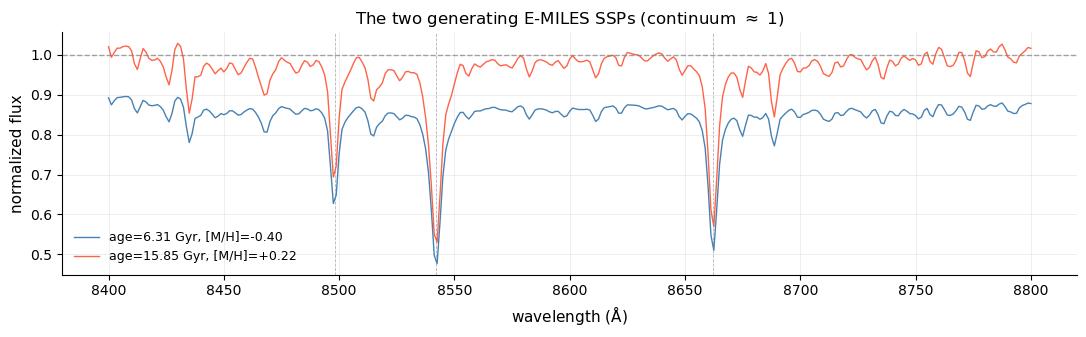

In [3]:
mask_plot = (wavelength >= 8400) & (wavelength <= 8800)

fig, ax = plt.subplots(figsize=(11, 3.5))
colors = ['steelblue', 'tomato']
for tpl, label, c in zip(templates, GEN_LABELS, colors):
    ax.plot(wavelength[mask_plot], tpl[mask_plot], lw=1.0, color=c, label=label)
for cen in [8498.02, 8542.09, 8662.14]:
    ax.axvline(cen, lw=0.6, color='grey', ls='--', alpha=0.6)
ax.axhline(1.0, lw=1.0, color='grey', ls='--', alpha=0.7)
ax.set_xlabel(r'wavelength ($\mathrm{\AA}$)')
ax.set_ylabel(r'normalized flux')
ax.set_title('The two generating E-MILES SSPs (continuum $\\approx$ 1)')
ax.legend(fontsize=9, framealpha=1.0, facecolor='white').set_zorder(20)
plt.tight_layout()
plt.show()

## 2. Build a synthetic galaxy spectrum with a complex continuum

We combine the two E-MILES SSPs with the known mixture weights (`TRUE_WEIGHTS`) into a
single population spectrum, convolve *that* with a Gaussian LOSVD (V = +80 km/s,
$\sigma$ = 60 km/s -- see the intro for why this value) -- mirroring the order the
fitting model itself uses (mix templates first, then apply one shared LOSVD
convolution) -- then multiply by a synthetic galaxy continuum: a cubic polynomial plus
a broad Gaussian hump, mimicking the overall shape of a cool-star-dominated galaxy SED.
This is the spectrum kinextract will receive: raw $\mathrm{erg/s/cm^2/\AA}$, no prior
normalization. Only the *spectrum* is synthetic here -- every template pixel is a real
E-MILES SSP.

In [4]:
WAVEFITMIN, WAVEFITMAX = 8000.0, 9000.0   # 1000 Å -- see the intro: a narrow ~335 Å
                                            # CaII-only window was found to leave real
                                            # velocity bias on the table at every sigma
                                            # tested, worst at high sigma; this wider
                                            # window (more independent spectral features
                                            # for the fit to use) measurably helps.
CEE, LAM_CENTER = 299792.458, 8580.0

TRUE_V     =  80.0   # km/s
TRUE_SIGMA =  60.0   # km/s -- matches the real N5102/N4751 regime; see the intro.

# ── Mix the SSPs, then convolve the population spectrum with the true LOSVD ──
pop_template = np.tensordot(TRUE_WEIGHTS, templates, axes=1)  # (N_PIX,)

sigma_pix = TRUE_SIGMA * LAM_CENTER / (CEE * STEP)
shift_pix = TRUE_V    * LAM_CENTER / (CEE * STEP)
RNG       = np.random.default_rng(42)
gal_norm  = ndimage_shift(gaussian_filter(pop_template, sigma_pix), +shift_pix)

# ── Galaxy continuum: cubic polynomial + broad Gaussian hump ─────────────────
# x_norm ∈ [-1, +1] across the full wavelength range.
# Produces a factor ~4 rise from blue to red with a broad hump near 7700 Å,
# roughly matching the SED of a cool-star-dominated galaxy.
# Include a small sinusoidal fringe pattern to mimic imperfect flat-fielding.

CONT_LEVEL = 12_000.0
x_norm = (wavelength - wavelength.mean()) / (0.5 * (wavelength[-1] - wavelength[0]))
slope  = 1.0 + 0.80 * x_norm + 0.5 * x_norm**2 - 0.10 * x_norm**3
hump   = 0.50 * np.exp(-0.5 * ((x_norm - 0.20) / 0.45)**2)
fringes = 0.01 * np.sin(2 * np.pi * (wavelength - wavelength[0]) / 50.0)
cont   = CONT_LEVEL * (slope + hump + fringes)

gal   = gal_norm * cont
NOISE = 250.0
gal  += RNG.normal(0.0, NOISE, N_PIX)
errs  = np.full(N_PIX, NOISE)

cat_mask = (wavelength >= WAVEFITMIN) & (wavelength <= WAVEFITMAX)
print(f"Galaxy continuum range:  {cont.min():.0f} - {cont.max():.0f}  erg/s/cm^2/angstrom$")
print(f"S/N in fit window:       "
      f"{cont[cat_mask].min() / NOISE:.0f} - {cont[cat_mask].max() / NOISE:.0f}")

# ── Save spectrum to a temp directory. Templates are NOT written here -- we fit ────
# with the full E-MILES fitting subgrid built in Section 3 below, the same way
# notebook 03 fits real MUSE data with its full template library.
tmpdir    = Path(tempfile.mkdtemp(prefix='kinextract_cont_'))
spec_path = tmpdir / 'mock_cont.spec'

np.savetxt(spec_path, np.column_stack([np.arange(1, N_PIX + 1), gal, errs]),
           fmt='%6d  %14.4f  %14.4f')
print(f"Spectrum written to {spec_path}")

Galaxy continuum range:  9162 - 27636  erg/s/cm^2/angstrom$
S/N in fit window:       89 - 103
Spectrum written to /var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_cont_jlrevnm5/mock_cont.spec


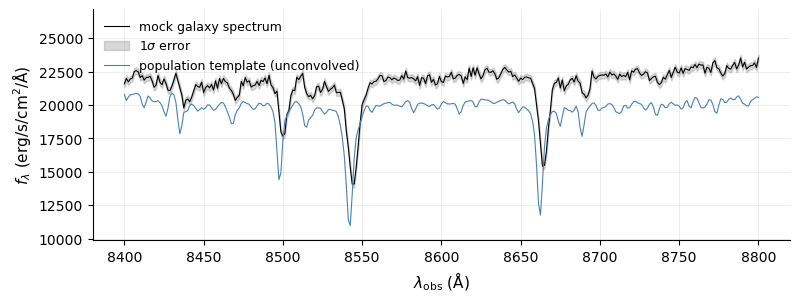

In [5]:
plt.figure(figsize=(9, 3))
plot_template = pop_template * np.median(gal[(wavelength >= 8000) & (wavelength <= 9000)])
plt.plot(wavelength[mask_plot], gal[mask_plot], lw=0.8, color='black', label='mock galaxy spectrum')
plt.fill_between(wavelength[mask_plot], gal[mask_plot] - errs[mask_plot], gal[mask_plot] + errs[mask_plot], color='grey', alpha=0.3, label=r'$1\sigma$ error')
plt.plot(wavelength[mask_plot], plot_template[mask_plot], lw=0.8, color='steelblue', label='population template (unconvolved)')
plt.xlabel(r'$\lambda_\mathrm{obs}$ ($\mathrm{\AA}$)')
plt.ylabel(r'$f_\lambda$ ($\mathrm{erg/s/cm^2/\AA}$)')
plt.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)

plt.ylim(0.9 * plot_template[(wavelength >= 8400) & (wavelength <= 8800)].min(), 
                1.3 * plot_template[(wavelength >= 8400) & (wavelength <= 8800)].max());

## 3. Fit with `fit_continuum = True`, using a larger E-MILES subgrid

Setting `fit_continuum=True` tells kinextract to estimate and remove the smooth
continuum inside the fitting loop (via `kinextract.joint`). The galaxy spectrum passed
in has raw $\mathrm{erg/s/cm^2/\AA}$ with the complex continuum intact — no
pre-normalization is needed.

We first write out a 20-SSP E-MILES subgrid (old, moderate-to-high metallicity
populations -- physically appropriate for an early-type/bulge-dominated target, and
the same subgrid validated in the stress-test log) as ordinary kinextract template
files, then fit with the *full* subgrid, not just the 2 SSPs that generated the mock --
the fit has to find the right combination on its own, exactly as it would on real data.

In [6]:
# ── Write out a 20-SSP E-MILES fitting subgrid (old, moderate-to-high metallicity) ──
FIT_AGE_IDX = [16, 18, 20, 22, 24]     # ages ~2.5-15.8 Gyr
FIT_METAL_IDX = [2, 3, 4, 5]           # [M/H] = -0.71 to +0.22
emiles_dir = tmpdir / 'emiles_fit_templates'
emiles_dir.mkdir()
fit_tlist_names = []
for ai in FIT_AGE_IDX:
    for mi in FIT_METAL_IDX:
        flux = load_emiles_ssp(ai, mi)
        name = f"emiles_a{ai}_m{mi}.dat"
        np.savetxt(emiles_dir / name, np.column_stack([wavelength, flux, np.full(N_PIX, 0.001)]),
                   fmt='%10.4f  %14.8f  %12.8f')
        fit_tlist_names.append(name)
(emiles_dir / 'Tlist').write_text('\n'.join(fit_tlist_names) + '\n')
print(f"{len(fit_tlist_names)} E-MILES templates written for fitting")

VRANGE = max(300.0, 3.5 * TRUE_SIGMA)

cfg = FitConfig(
    template_list_file  = str(emiles_dir / 'Tlist'),
    template_dir        = str(emiles_dir),
    # outdir=str(tmpdir), write_outputs=True,  # uncomment to save .fit/.temp/.ascii/.rms output files
    wavemin_full        = WAVEMIN,
    step                = STEP,
    wavefitmin          = WAVEFITMIN,
    wavefitmax          = WAVEFITMAX,
    zgal                = 0.0,
    fit_continuum       = True,          # <-- key option
    use_spectrum_errors = True,
    xlam_auto           = True,
    losvd_vmin          = -VRANGE,       # km/s -- matched to TRUE_SIGMA
    losvd_vmax          = +VRANGE,       # km/s
    sigl                = TRUE_SIGMA,
    clean               = False,
    map_maxiter         = 10000,
    print_every         = 999999,
)

fit = run_spectral_fit(cfg, gal_file=str(spec_path))
st  = fit['state']
out = fit['outputs']
b   = out['b']
gp  = out['gp']
print(f"chisquared_reduced = {out['chi2_red']:.3f}")
print(f"xlam chosen = {st.xlam:.1f}")
print(f"success     : {fit['result'].success}")
if not fit['result'].success:
    print(f"  WARNING: L-BFGS-B did not converge ({fit['result'].message}) -- treat "
          "V/sigma/h3/h4 as unreliable; consider raising map_maxiter or loosening map_ftol.")

# Bonus check: how much of the recovered template weight landed on the 2 SSPs that
# actually generated the mock, vs. leaking onto the other 18 (some real SSP-mixture
# degeneracy is expected, and it doesn't necessarily hurt the kinematics -- see the
# printed V/sigma below).
gen_names = [f"emiles_a{a}_m{m}.dat" for a, m in GEN_AGE_METAL]
w_rec = np.asarray(out['w'], float)
w_rec = w_rec / w_rec.sum()
gen_idx = [fit_tlist_names.index(n) for n in gen_names]
print(f"\nRecovered weight on the 2 true generating SSPs: {np.round(w_rec[gen_idx], 3)}"
      f"  (sum={w_rec[gen_idx].sum():.3f} of 1.0)")

20 E-MILES templates written for fitting


chisquared_reduced = 1.027
xlam chosen = 80584.2
success     : True

Recovered weight on the 2 true generating SSPs: [0.099 0.367]  (sum=0.465 of 1.0)


## 4. Extract GH moments from the recovered LOSVD

In [7]:
gh = fit_losvd_gauss_hermite(st.xl, b, fit_h3h4=True)
print(f"Recovered:  V = {gh['vherm']:+.1f}  sigma = {gh['sherm']:.1f}  "
      f"h3 = {gh['h3']:+.4f}  h4 = {gh['h4']:+.4f}")
print(f"Truth:      V = {TRUE_V:+.1f}  sigma = {TRUE_SIGMA:.1f}")

Recovered:  V = +79.7  sigma = 63.0  h3 = -0.0061  h4 = -0.0156
Truth:      V = +80.0  sigma = 60.0


## 5. Diagnostic plots

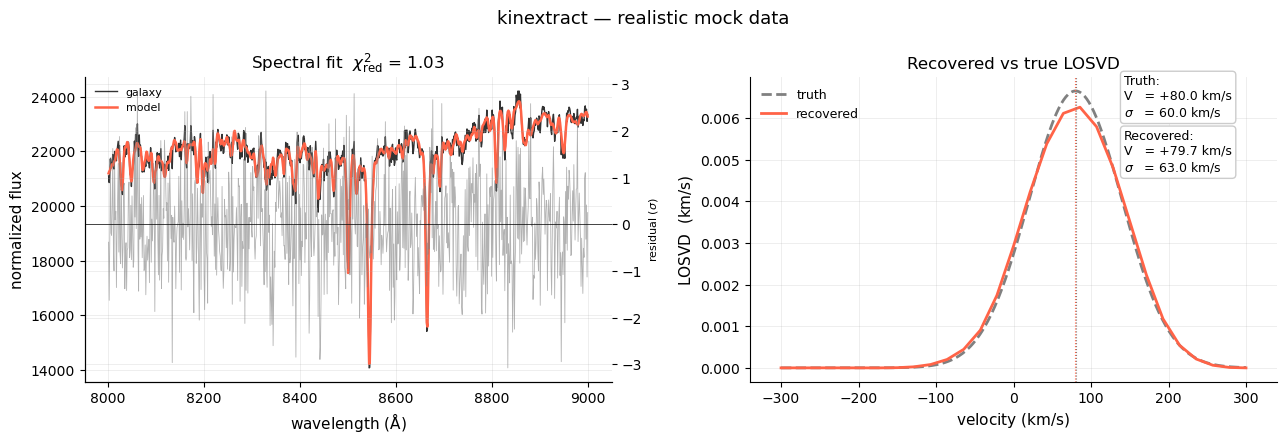

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('kinextract — realistic mock data', fontsize=13)

# ── Panel 1: normalized residual ─────────────────────────────────────────────
ax = axes[0]
ax.plot(st.x, st.g,  lw=1.0, color='black', label='galaxy', alpha=0.8)
ax.plot(st.x, gp, lw=1.8, color='tomato', label='model', zorder=3)
resid = (st.g - gp) / np.nanmedian(st.gerr[st.gerr < 1e9])
ax2 = ax.twinx()
ax2.plot(st.x, resid, lw=0.6, color='grey', alpha=0.6)
ax2.axhline(0, lw=0.5, color='k')
ax2.set_ylabel(r'residual ($\sigma$)', fontsize=8)
ax.set_xlabel(r'wavelength ($\mathrm{\AA}$)')
ax.set_ylabel(r'normalized flux')
ax.set_title(r'Spectral fit  $\chi^2_{\rm red}$ = ' + f"{out['chi2_red']:.2f}")
ax.legend(fontsize=8, framealpha=1.0, facecolor='white').set_zorder(20)

# ── Panel 2: LOSVD ────────────────────────────────────────────────────────────
ax = axes[1]
v_true = np.linspace(cfg.losvd_vmin, cfg.losvd_vmax, 401)
b_true = np.exp(-0.5 * ((v_true - TRUE_V) / TRUE_SIGMA) ** 2)
b_true /= trapezoid(b_true, v_true)
b_rec   = b / trapezoid(b, st.xl)

ax.plot(v_true, b_true, lw=2.0, color='grey',  ls='--', label='truth')
ax.plot(st.xl,  b_rec,  lw=2.0, color='tomato',         label='recovered')
ax.axvline(TRUE_V,       lw=0.8, color='grey',  ls=':')
ax.axvline(gh['vherm'],  lw=0.8, color='tomato', ls=':')


ax.text(0.71, 0.86,
        f"Truth:\n"
        f"V   = {TRUE_V:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {TRUE_SIGMA:.1f} km/s",
        transform=ax.transAxes, fontsize=9, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.text(0.71, 0.68,
        f"Recovered:\n"
        f"V   = {gh['vherm']:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {gh['sherm']:.1f} km/s",
        transform=ax.transAxes, fontsize=9, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel(r'velocity ($\mathrm{km/s}$)')
ax.set_ylabel(r'LOSVD  ($\mathrm{km/s}$)')
ax.set_title('Recovered vs true LOSVD')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin-40, cfg.losvd_vmax+40)

plt.tight_layout()
plt.show()

## 6. Error estimation

Uncertainty on the LOSVD is estimated via **residual bootstrap**: resample fit residuals into synthetic spectra and refit each through the same pipeline (here, `kinextract.joint`, at the main fit's own converged xlam/sigl0/v_center) -> an independent, frequentist estimate of the LOSVD's scatter. Slower than a closed-form approximation since each of `N_BOOT` replicates is a full refit, but the only supported method for continuum-cofit fits: `laplace_covariance`/`bias_correction` don't yet understand the joint method's parameter layout and raise `NotImplementedError`.

In [9]:
from kinextract import LOSVDErrorEstimator

N_BOOT = 50   # increase to ≥200 for publication

est     = LOSVDErrorEstimator(fit, cfg)
boot    = est.residual_bootstrap(n_bootstrap=N_BOOT, n_jobs=4)
summary = est.summarize(bootstrap_result=boot)

gh_map = summary['gh_map']
gh_err = summary.get('gh_err_recommended', {})
print("Bootstrap uncertainties:")
for label, mkey, ekey in [('V', 'vherm', 'gh_vherm'), ('σ', 'sherm', 'gh_sherm'),
                           ('h3', 'h3', 'gh_h3'), ('h4', 'h4', 'gh_h4')]:
    val = gh_map.get(mkey)
    err = gh_err.get(ekey)
    if val is not None:
        err_str = f' ± {err:.2f}' if err is not None else ''
        unit = ' km/s' if label in ('V', 'σ') else ''
        print(f'  {label:5s} = {val:+.2f}{unit}{err_str}')

[LOSVDErrors] Starting residual bootstrap (n=50, block=1, jobs=4)...
[LOSVDErrors] Using 4 worker threads


[LOSVDErrors] Bootstrap 5/50 (3s elapsed)


[LOSVDErrors] Bootstrap 10/50 (4s elapsed)


[LOSVDErrors] Bootstrap 15/50 (6s elapsed)


[LOSVDErrors] Bootstrap 20/50 (8s elapsed)


...

[LOSVDErrors] Bootstrap 30/50 (12s elapsed)


[LOSVDErrors] Bootstrap 35/50 (14s elapsed)


[LOSVDErrors] Bootstrap 40/50 (16s elapsed)


[LOSVDErrors] Bootstrap 45/50 (17s elapsed)


[LOSVDErrors] Bootstrap 50/50 (18s elapsed)
[LOSVDErrors] Bootstrap done in 18.3s. Success: 50/50

LOSVD ERROR SUMMARY
  Gauss-Hermite moments (MAP, consistent with pallmc.f):
    V    = +79.74 km/s ± 1.76
    σ    = 63.00 km/s ± 1.29
    h3   = -0.0061 ± 0.0149
    h4   = -0.0156 ± 0.0076
  LOSVD moments (for reference):
    V    = +78.81 km/s ± 1.80
    σ    = 61.59 km/s ± 2.30

  Bootstrap: 50 successful / 50 total replicates

Bootstrap uncertainties:
  V     = +79.74 km/s ± 1.76
  σ     = +63.00 km/s ± 1.29
  h3    = -0.01 ± 0.01
  h4    = -0.02 ± 0.01


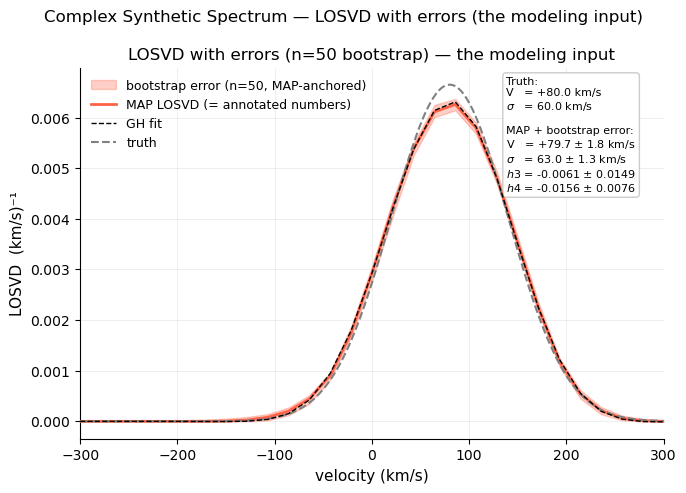

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Complex Synthetic Spectrum — LOSVD with errors (the modeling input)', fontsize=12)

b_trap   = trapezoid(b, st.xl)
b_norm   = b / b_trap

# Error bounds are MAP-anchored (summary['b_lo_recommended']/['b_hi_recommended']),
# matching the legacy pipeline's actual modeling-input convention: traced
# directly through mcfitw.f -> pallmc.f's .mcfit2 section -> transvd -> the
# final *_in files the Schwarzschild-modeling stage reads. .mcfit2 uses the
# bootstrap ensemble's biweight location only to measure how far the
# 16th/84th percentiles sit from it, then transplants that *distance* onto
# the MAP fit's own value -- never onto the ensemble's own location (see
# errors.py's _map_anchored_bounds). So this curve -- MAP LOSVD, plus these
# MAP-anchored bounds -- is the *_in-equivalent LOSVD-with-errors: what
# actually corresponds to what goes into modeling. There is no separate
# "bootstrap median" curve to show; the ensemble is only ever used for its
# spread, never as an alternative central estimate.
b_lo = summary['b_lo_recommended'] / b_trap
b_hi = summary['b_hi_recommended'] / b_trap

gh_med = summary['gh_center_recommended']
gh_model_norm = gh_med['model'] / trapezoid(gh_med['model'], st.xl)

ax.fill_between(st.xl, b_lo, b_hi, alpha=0.30, color='tomato',
                label=f'bootstrap error (n={N_BOOT}, MAP-anchored)')
ax.plot(st.xl, b_norm, lw=2.0, color='tomato', zorder=5, label='MAP LOSVD (= annotated numbers)')
ax.plot(st.xl, gh_model_norm, lw=1.0, ls='--', color='black', zorder=6, label='GH fit')
ax.plot(v_true, b_true, lw=1.5, color='grey', ls='--', label='truth', zorder=5)

ax.text(0.73, 0.66,
        f"Truth:           \n"
        f"V   = {TRUE_V:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {TRUE_SIGMA:.1f} km/s\n\n"
        f"MAP + bootstrap error:\n"
        fr"V   = {gh_med['vherm']:+.1f} $\pm$ {gh_err.get('gh_vherm', float('nan')):.1f}" + " km/s\n"
        fr"$\sigma$   = {gh_med['sherm']:.1f} $\pm$ {gh_err.get('gh_sherm', float('nan')):.1f}" + " km/s\n"
        fr"$h3$ = {gh_med['h3']:+.4f} $\pm$ {gh_err.get('gh_h3', float('nan')):.4f}" + "\n"
        fr"$h4$ = {gh_med['h4']:+.4f} $\pm$ {gh_err.get('gh_h4', float('nan')):.4f}",
        transform=ax.transAxes, fontsize=8, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel('velocity (km/s)'); ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title(f'LOSVD with errors (n={N_BOOT} bootstrap) — the modeling input')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

plt.tight_layout()
plt.show()

In [11]:
b_true_interp = np.interp(st.xl, v_true, b_true)

# Fractional residuals
frac_residual = (b_norm - b_true_interp) / b_true_interp

# Corresponding 16th/84th percentile envelope
frac_residual_lo = (b_lo - b_true_interp) / b_true_interp
frac_residual_hi = (b_hi - b_true_interp) / b_true_interp

print(frac_residual)

[ 2.66796155e+03  3.02912443e+03  8.02523716e+02  1.34911816e+02
  1.20845197e+01 -8.39137289e-01 -9.66193677e-01  1.34364256e-01
  6.09832289e-01  5.59370501e-01  3.75433171e-01  2.06761306e-01
  1.06180233e-01  9.34698821e-02  7.01489132e-02  2.28174915e-02
 -2.00790756e-02 -4.87333849e-02 -5.42504857e-02 -3.50938114e-02
  2.46807256e-03  4.54628263e-02  7.29528774e-02  3.91651116e-02
 -1.72921302e-03 -7.15147807e-02 -2.54357254e-01 -6.31540985e-01
 -9.95677358e-01]


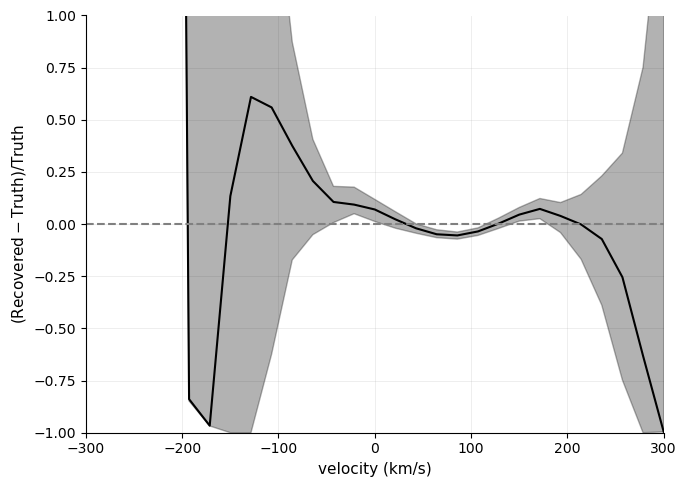

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(st.xl, frac_residual, color='k')
ax.fill_between(st.xl, frac_residual_lo, frac_residual_hi,
                color='k', alpha=0.3)
ax.axhline(0, color='gray', ls='--')
ax.set_ylim(-1, 1)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)
ax.set_xlabel('velocity (km/s)')
ax.set_ylabel(r'$(\mathrm{Recovered}-\mathrm{Truth})/\mathrm{Truth}$')
plt.tight_layout()
plt.show()